# Project 3: Vulnerability Fusion Engine  
This notebook supports the first stage of our project: selecting datasets, doing basic exploration, identifying vulnerability signals, and building a first-pass cross-domain vulnerability logic.

## Data sources used this week
1. `insurance_claims 2.csv` for car-insurance-related signals  
2. `insurance.csv` for health-insurance-related signals  
3. CDC Community & Connection page for loneliness and social support context

## This week's goal
- load and inspect the datasets  
- clean obvious issues  
- create basic summary statistics  
- make a few visualizations  
- define vulnerability signals in each domain  
- build a **conceptual** combined vulnerability framework

**Important note:** this project does **not** directly merge real people across datasets. Instead, it combines separate public data sources as stand-ins for different forms of vulnerability.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 5)
pd.set_option('display.max_columns', 100)

car_path = 'insurance_claims 2.csv'
health_path = 'insurance.csv'

car = pd.read_csv(car_path)
health = pd.read_csv(health_path)

print('Car insurance shape:', car.shape)
print('Health insurance shape:', health.shape)

Car insurance shape: (1000, 40)
Health insurance shape: (1338, 7)


In [2]:
# quick inspection
display(car.head())
display(health.head())

print('Car columns:')
print(car.columns.tolist())

print('\nHealth columns:')
print(health.columns.tolist())

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital-gains,capital-loss,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,MALE,MD,craft-repair,sleeping,husband,53300,0,2015-01-25,Single Vehicle Collision,Side Collision,Major Damage,Police,SC,Columbus,9935 4th Drive,5,1,YES,1,2,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,MALE,MD,machine-op-inspct,reading,other-relative,0,0,2015-01-21,Vehicle Theft,?,Minor Damage,Police,VA,Riverwood,6608 MLK Hwy,8,1,?,0,0,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,FEMALE,PhD,sales,board-games,own-child,35100,0,2015-02-22,Multi-vehicle Collision,Rear Collision,Minor Damage,Police,NY,Columbus,7121 Francis Lane,7,3,NO,2,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,FEMALE,PhD,armed-forces,board-games,unmarried,48900,-62400,2015-01-10,Single Vehicle Collision,Front Collision,Major Damage,Police,OH,Arlington,6956 Maple Drive,5,1,?,1,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,MALE,Associate,sales,board-games,unmarried,66000,-46000,2015-02-17,Vehicle Theft,?,Minor Damage,NaN,NY,Arlington,3041 3rd Ave,20,1,NO,0,1,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Car columns:
['months_as_customer', 'age', 'policy_number', 'policy_bind_date', 'policy_state', 'policy_csl', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'insured_zip', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'capital-gains', 'capital-loss', 'incident_date', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'incident_location', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'property_damage', 'bodily_injuries', 'witnesses', 'police_report_available', 'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim', 'auto_make', 'auto_model', 'auto_year', 'fraud_reported', '_c39']

Health columns:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


## 1. Basic cleaning

The car insurance file includes one obviously empty column called `_c39`.  
We remove that and check missing values in both datasets.


In [3]:
# remove clearly empty column if needed
if '_c39' in car.columns:
    car = car.drop(columns=['_c39'])

print('Missing values in car dataset:')
display(car.isna().sum().sort_values(ascending=False).head(15))

print('\nMissing values in health dataset:')
display(health.isna().sum().sort_values(ascending=False))

Missing values in car dataset:


authorities_contacted          91
witnesses                       0
incident_state                  0
incident_city                   0
incident_location               0
incident_hour_of_the_day        0
number_of_vehicles_involved     0
property_damage                 0
bodily_injuries                 0
months_as_customer              0
incident_severity               0
total_claim_amount              0
injury_claim                    0
property_claim                  0
vehicle_claim                   0
dtype: int64


Missing values in health dataset:


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

## 2. Car insurance dataset exploration

For the car insurance domain, we want to identify variables that could be framed as **financial or transportation vulnerability signals** in an unethical system.

Possible signals:
- higher annual premium
- higher deductible
- larger total claim amount
- more severe incidents
- larger capital loss or lower financial cushion


In [4]:
car[['age','policy_deductable','policy_annual_premium','capital-gains','capital-loss',
     'total_claim_amount','injury_claim','property_claim','vehicle_claim']].describe().T

,count,mean,std,min,25%,50%,75%,max
age,1000.0,38.94800,9.140287,19.00,32.0000,38.0,44.000,64.00
policy_deductable,1000.0,1136.00000,611.864673,500.00,500.0000,1000.0,2000.000,2000.00
policy_annual_premium,1000.0,1256.40615,244.167395,433.33,1089.6075,1257.2,1415.695,2047.59
capital-gains,1000.0,25126.10000,27872.187708,0.00,0.0000,0.0,51025.000,100500.00
capital-loss,1000.0,-26793.70000,28104.096686,-111100.00,-51500.0000,-23250.0,0.000,0.00
total_claim_amount,1000.0,52761.94000,26401.533190,100.00,41812.5000,58055.0,70592.500,114920.00
injury_claim,1000.0,7433.42000,4880.951853,0.00,4295.0000,6775.0,11305.000,21450.00
property_claim,1000.0,7399.57000,4824.726179,0.00,4445.0000,6750.0,10885.000,23670.00
vehicle_claim,1000.0,37928.95000,18886.252893,70.00,30292.5000,42100.0,50822.500,79560.00


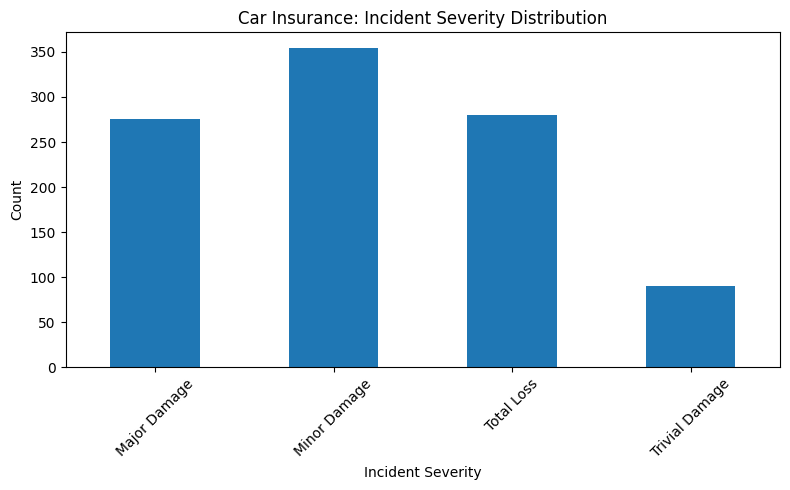

In [5]:
# incident severity distribution
severity_counts = car['incident_severity'].value_counts().sort_index()
severity_counts.plot(kind='bar')
plt.title('Car Insurance: Incident Severity Distribution')
plt.xlabel('Incident Severity')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

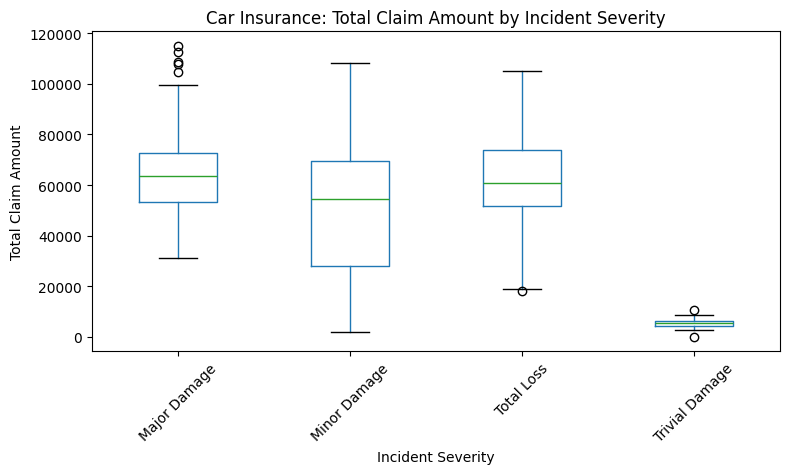

In [6]:
# total claim amount by incident severity
severity_order = ['Minor Damage', 'Major Damage', 'Total Loss', 'Trivial Damage']
car.boxplot(column='total_claim_amount', by='incident_severity', grid=False)
plt.title('Car Insurance: Total Claim Amount by Incident Severity')
plt.suptitle('')
plt.xlabel('Incident Severity')
plt.ylabel('Total Claim Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

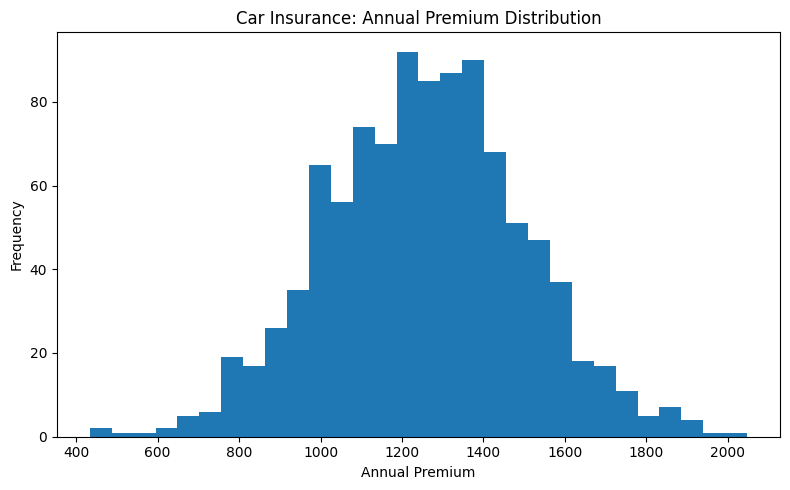

In [7]:
# premium distribution
car['policy_annual_premium'].plot(kind='hist', bins=30)
plt.title('Car Insurance: Annual Premium Distribution')
plt.xlabel('Annual Premium')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### First-pass car vulnerability score

This is not a real actuarial model.  
It is only a simple exploratory score to show how an unethical actor might turn multiple features into a vulnerability signal.


In [8]:
# build a simple exploratory vulnerability score for the car insurance dataset
car_score = car.copy()

severity_map = {
    'Trivial Damage': 0,
    'Minor Damage': 1,
    'Major Damage': 2,
    'Total Loss': 3
}

car_score['severity_num'] = car_score['incident_severity'].map(severity_map)

# min-max scaling helper
def minmax(s):
    s = s.astype(float)
    return (s - s.min()) / (s.max() - s.min())

car_score['car_vulnerability_score'] = (
    0.25 * minmax(car_score['policy_annual_premium']) +
    0.20 * minmax(car_score['policy_deductable']) +
    0.25 * minmax(car_score['total_claim_amount']) +
    0.15 * minmax(car_score['capital-loss']) +
    0.15 * minmax(car_score['severity_num'])
)

car_score[['policy_annual_premium','policy_deductable','total_claim_amount',
           'capital-loss','incident_severity','car_vulnerability_score']].head()

,policy_annual_premium,policy_deductable,total_claim_amount,capital-loss,incident_severity,car_vulnerability_score
0,1406.91,1000,71610,0,Major Damage,0.623145
1,1197.22,2000,5070,0,Minor Damage,0.529125
2,1413.14,2000,34650,0,Minor Damage,0.626969
3,1415.74,2000,63400,-62400,Major Damage,0.655722
4,1583.91,1000,6500,-46000,Minor Damage,0.396685


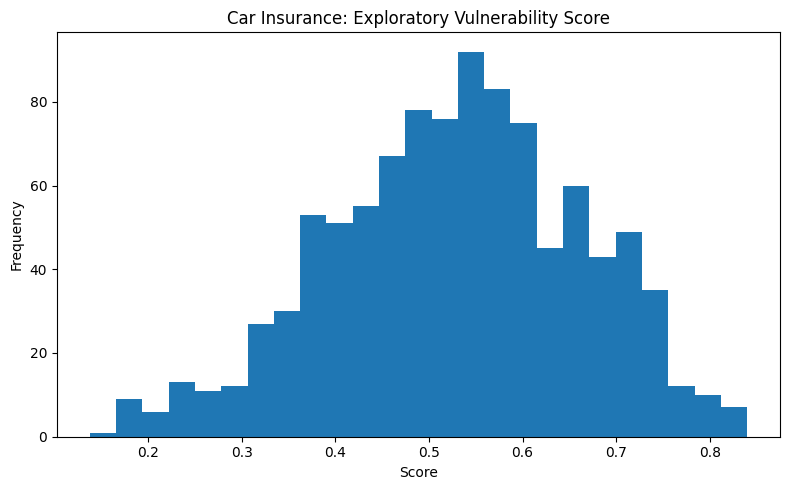

Top 10 highest car vulnerability cases:


,age,policy_annual_premium,policy_deductable,capital-loss,incident_severity,total_claim_amount,car_vulnerability_score
608,46,1546.01,2000,0,Total Loss,77100,0.839974
732,26,1509.04,2000,0,Total Loss,78320,0.836905
400,53,1459.93,2000,0,Total Loss,77990,0.828581
214,33,1362.64,2000,0,Total Loss,81360,0.820851
718,44,1655.79,2000,0,Minor Damage,105820,0.819508
64,42,1641.73,2000,0,Total Loss,59130,0.815672
320,37,1603.42,2000,-30200,Total Loss,80520,0.815538
417,37,1628.00,2000,0,Total Loss,55600,0.805860
23,55,1268.79,2000,-31000,Total Loss,98160,0.801041
521,26,1137.02,2000,0,Total Loss,88110,0.800606


In [9]:
car_score['car_vulnerability_score'].plot(kind='hist', bins=25)
plt.title('Car Insurance: Exploratory Vulnerability Score')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print('Top 10 highest car vulnerability cases:')
display(car_score.sort_values('car_vulnerability_score', ascending=False)[[
    'age','policy_annual_premium','policy_deductable','capital-loss',
    'incident_severity','total_claim_amount','car_vulnerability_score'
]].head(10))

## 3. Health insurance dataset exploration

For the health insurance domain, we want variables that can be framed as **medical or financial vulnerability signals**.

Possible signals:
- higher medical charges
- smoking
- higher BMI
- older age
- more dependents or care burden


In [10]:
health.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1338.0,NaN,NaN,NaN,39.207025,14.04996,18.0,27.0,39.0,51.0,64.0
sex,1338,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1338.0,NaN,NaN,NaN,30.663397,6.098187,15.96,26.29625,30.4,34.69375,53.13
children,1338.0,NaN,NaN,NaN,1.094918,1.205493,0.0,0.0,1.0,2.0,5.0
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1338,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,1338.0,NaN,NaN,NaN,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


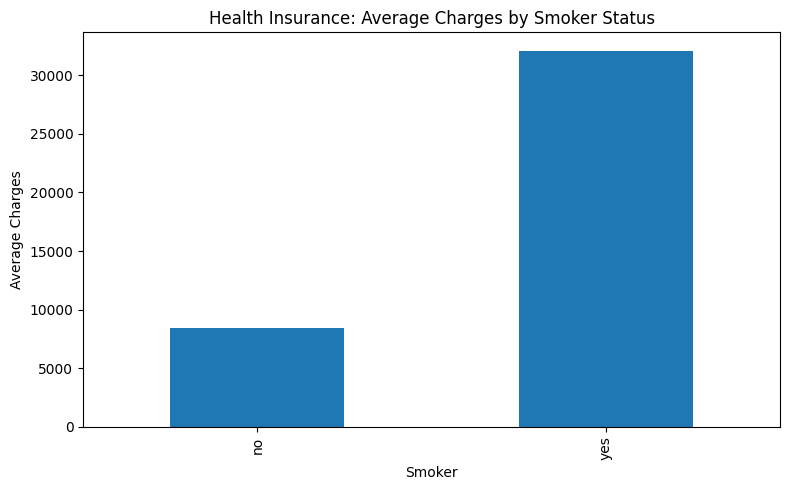

smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64

In [11]:
# average charges by smoker
charges_by_smoker = health.groupby('smoker')['charges'].mean().sort_values()
charges_by_smoker.plot(kind='bar')
plt.title('Health Insurance: Average Charges by Smoker Status')
plt.xlabel('Smoker')
plt.ylabel('Average Charges')
plt.tight_layout()
plt.show()

display(charges_by_smoker)

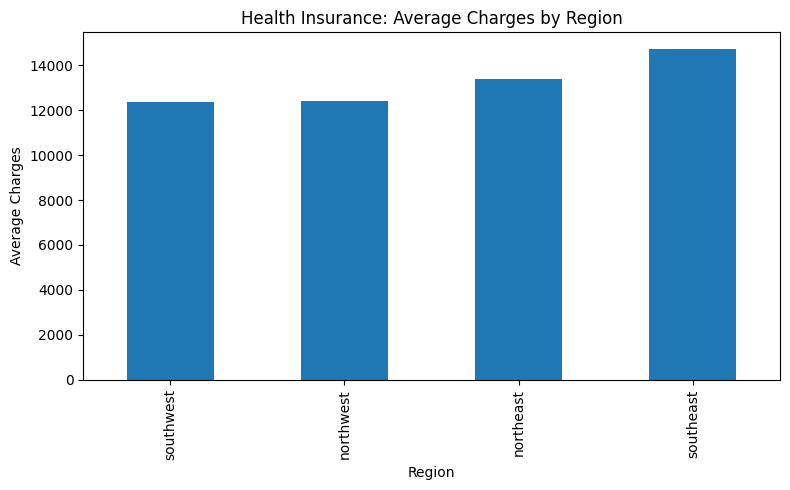

In [12]:
# charges by region
health.groupby('region')['charges'].mean().sort_values().plot(kind='bar')
plt.title('Health Insurance: Average Charges by Region')
plt.xlabel('Region')
plt.ylabel('Average Charges')
plt.tight_layout()
plt.show()

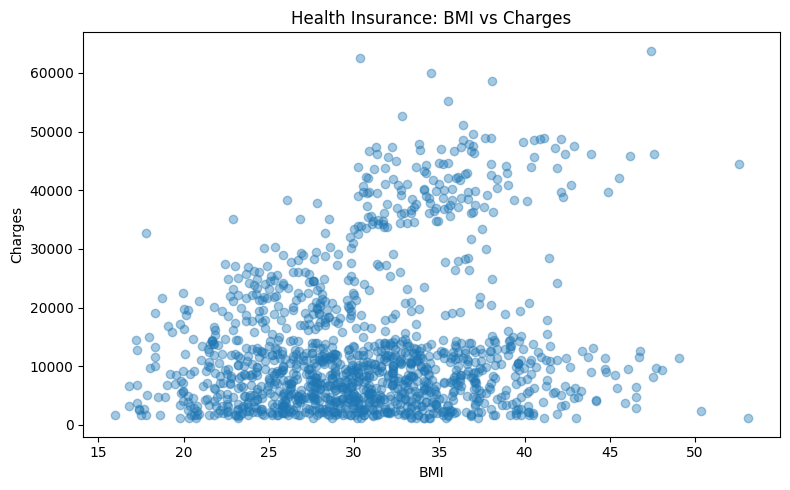

In [13]:
# bmi vs charges
plt.scatter(health['bmi'], health['charges'], alpha=0.4)
plt.title('Health Insurance: BMI vs Charges')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.tight_layout()
plt.show()

### First-pass health vulnerability score

Again, this is only a simple exploratory score for the project idea.


In [14]:
health_score = health.copy()

health_score['smoker_num'] = health_score['smoker'].map({'no':0, 'yes':1})

health_score['health_vulnerability_score'] = (
    0.40 * minmax(health_score['charges']) +
    0.20 * minmax(health_score['bmi']) +
    0.20 * minmax(health_score['age']) +
    0.10 * minmax(health_score['children']) +
    0.10 * health_score['smoker_num']
)

health_score[['age','bmi','children','smoker','charges','health_vulnerability_score']].head()

,age,bmi,children,smoker,charges,health_vulnerability_score
0,19,27.900,0,yes,16884.92400,0.269237
1,18,33.770,1,no,1725.55230,0.119684
2,28,33.000,3,no,4449.46200,0.216411
3,33,22.705,0,no,21984.47061,0.234714
4,32,28.880,0,no,3866.85520,0.147914


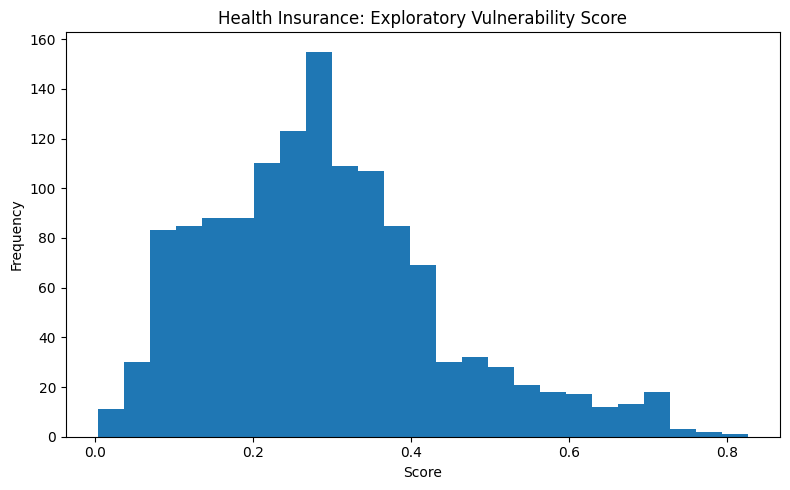

Top 10 highest health vulnerability cases:


,age,bmi,children,smoker,region,charges,health_vulnerability_score
543,54,47.410,0,yes,southeast,63770.42801,0.825744
1230,52,34.485,3,yes,northwest,60021.39897,0.783566
1241,64,36.960,2,yes,southeast,49577.66240,0.762376
281,54,40.565,3,yes,northeast,48549.17835,0.751728
1062,59,41.140,1,yes,southeast,48970.24760,0.739250
530,57,42.130,1,yes,southeast,48675.51770,0.733999
951,51,42.900,2,yes,southeast,47462.89400,0.724313
55,58,36.955,2,yes,northwest,47496.49445,0.722974
1301,62,30.875,3,yes,northwest,46718.16325,0.722682
1240,52,41.800,2,yes,southeast,47269.85400,0.721510


In [15]:
health_score['health_vulnerability_score'].plot(kind='hist', bins=25)
plt.title('Health Insurance: Exploratory Vulnerability Score')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print('Top 10 highest health vulnerability cases:')
display(health_score.sort_values('health_vulnerability_score', ascending=False)[[
    'age','bmi','children','smoker','region','charges','health_vulnerability_score'
]].head(10))

## 4. CDC loneliness / social support context

We do not have an uploaded raw loneliness file this week, so we use **official CDC summary figures** to build the social-vulnerability part of the project.

From CDC Community & Connection:
- The page provides national and state-level youth and adult data on loneliness, social connection, and social support.
- Most recent 2021 data show **82%** of U.S. adults felt they received the social and emotional support they needed.
- Most recent 2024 data show **12%** of U.S. adults had difficulty participating in social activities due to a physical, mental, or emotional condition.
- The page also includes adult loneliness percentages by state or territory and explains that these can be compared using percentile groups.

We use these official summary values as a first-pass proxy for the social-vulnerability domain.


In [16]:
# Build a simple CDC summary table from the official page
cdc_summary = pd.DataFrame({
    'metric': [
        'Adults receiving needed social/emotional support',
        'Adults unable to participate in social activities due to condition'
    ],
    'percent': [82, 12],
    'direction_for_vulnerability': ['lower support = worse', 'higher limitation = worse']
})

display(cdc_summary)

,metric,percent,direction_for_vulnerability
0,Adults receiving needed social/emotional support,82,lower support = worse
1,Adults unable to participate in social activit...,12,higher limitation = worse


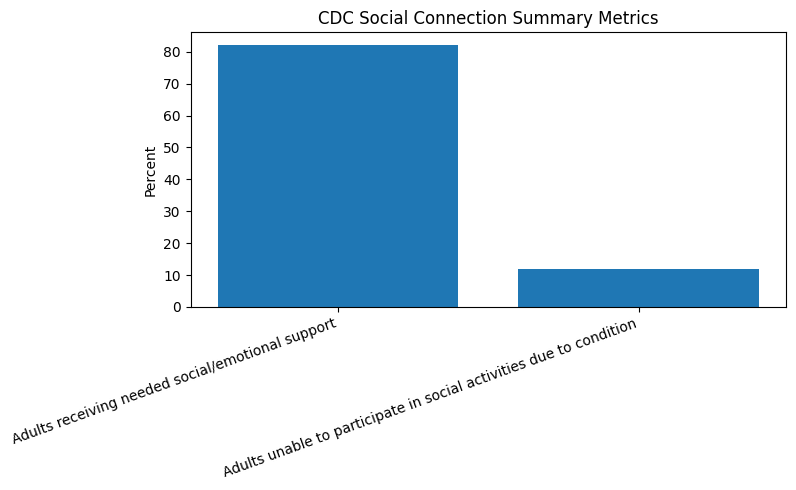

In [17]:
# simple visualization of CDC summary metrics
plt.bar(cdc_summary['metric'], cdc_summary['percent'])
plt.title('CDC Social Connection Summary Metrics')
plt.ylabel('Percent')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

### Interpreting the social-vulnerability domain

For our project, the social domain does not need to be individual-level this week.  
It is enough to show that official CDC data supports the idea that loneliness, lack of support, and limits on social activity are meaningful indicators of vulnerability in the U.S.


## 5. Combine the three domains conceptually

This week, instead of forcing a direct merge, we combine the domains at the **concept level**.

- Car insurance domain → transportation and financial exposure  
- Health insurance domain → medical and financial burden  
- Social connection domain → weaker support and lower resilience  

An unethical organization could combine these signals into a broader profile of who is easier to exploit.


In [18]:
# domain-level summary table
domain_summary = pd.DataFrame({
    'domain': ['Car insurance', 'Health insurance', 'Loneliness / social connection'],
    'key_signal': [
        'High premiums, deductibles, claims, severe incidents',
        'High medical charges, smoking, BMI, age',
        'Low support and limits on social participation'
    ],
    'example_indicator_from_this_week': [
        round(car_score['car_vulnerability_score'].mean(), 3),
        round(health_score['health_vulnerability_score'].mean(), 3),
        1 - 0.82 + 0.12   # simple conceptual index using CDC summary stats
    ]
})

display(domain_summary)

,domain,key_signal,example_indicator_from_this_week
0,Car insurance,"High premiums, deductibles, claims, severe inc...",0.528
1,Health insurance,"High medical charges, smoking, BMI, age",0.291
2,Loneliness / social connection,Low support and limits on social participation,0.300


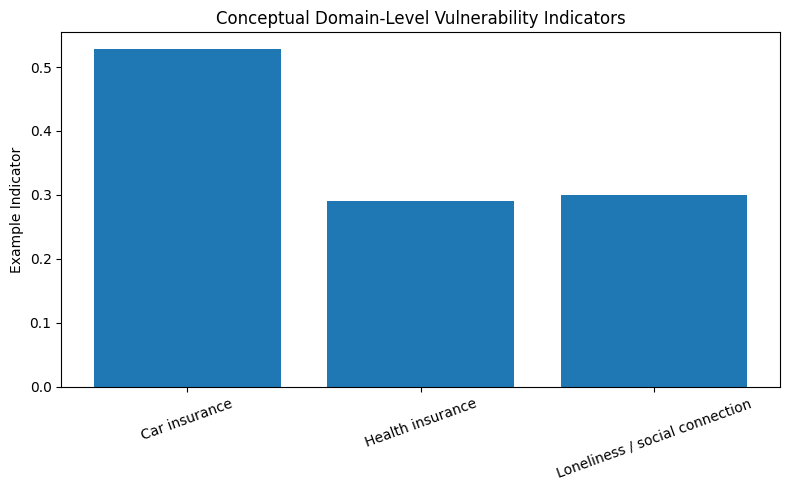

In [19]:
# visualize conceptual domain pressure
plt.bar(domain_summary['domain'], domain_summary['example_indicator_from_this_week'])
plt.title('Conceptual Domain-Level Vulnerability Indicators')
plt.ylabel('Example Indicator')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 6. Key findings for this week's milestone

1. The car insurance dataset can support a vulnerability story through premiums, deductibles, claims, and incident severity.  
2. The health insurance dataset can support a vulnerability story through charges, smoking, BMI, and age.  
3. The CDC page gives official support for the loneliness / social connection domain, even if we do not yet have a clean raw CSV for that part.  
4. The three domains are better combined conceptually than through a forced row-level merge.  
5. This is enough progress for the current milestone: dataset confirmation, basic exploration, visualizations, and first-pass vulnerability logic.


## 7. Next steps

- decide whether to keep the CDC summary approach or add a cleaner loneliness dataset  
- refine the vulnerability scoring logic  
- select the strongest 2–3 charts for the presentation  
- write the ethics section around privacy, proxy discrimination, unfair targeting, and misleading storytelling
